In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.edgecolor': '0.3'})
sns.set_context("paper", font_scale=1.2)  # Paper-optimized settings


def plot_citation_distribution(br_publications):
    # Preprocess the data
    def is_international(authorships_str):
        try:
            authorships = json.loads(authorships_str.replace("'", '"'))
            for author in authorships:
                if "countries" in author and author["countries"]:
                    if any(country != "BR" for country in author["countries"]):
                        return True
            return False
        except:
            return False

    # Classify publications
    br_publications["is_international"] = br_publications["authorships"].apply(
        is_international
    )

    # Prepare data for plotting
    domestic = br_publications[~br_publications["is_international"]]
    international = br_publications[br_publications["is_international"]]

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)

    # Plot domestic publications
    sns.scatterplot(
        x=domestic["cited_by_count"].value_counts().index,
        y=domestic["cited_by_count"].value_counts().values,
        ax=axes[0],
        color="blue",
        alpha=0.7,
    )
    
    axes[0].set_title("Domestic Collaborations")
    axes[0].set_xlabel("Citation Count")
    axes[0].set_ylabel("Number of Publications")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")

    # Plot international publications
    sns.scatterplot(
        x=international["cited_by_count"].value_counts().index,
        y=international["cited_by_count"].value_counts().values,
        ax=axes[1],
        color="orange",
        alpha=0.7,
    )
    axes[1].set_title("International Collaborations")
    axes[1].set_xlabel("Citation Count")
    axes[1].set_ylabel("")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    plt.tight_layout()
    return fig

In [2]:
def plot_subfield_collaboration(subfields_collab_df):
    # Split data
    single = subfields_collab_df[subfields_collab_df['collab_type'] == 'Single-Subfield']
    multi = subfields_collab_df[subfields_collab_df['collab_type'] == 'Multi-Subfield']
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)
    
    # Plot single-subfield
    sns.scatterplot(
        x=single['cited_by_count'].value_counts().index,
        y=single['cited_by_count'].value_counts().values,
        ax=axes[0],
        color='green',
        alpha=0.7
    )
    
    axes[0].set_title('Single-Subfield Collaborations')
    axes[0].set_xlabel('Citation Count')
    axes[0].set_ylabel('Number of Publications')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
    # Plot multi-subfield
    sns.scatterplot(
        x=multi['cited_by_count'].value_counts().index,
        y=multi['cited_by_count'].value_counts().values,
        ax=axes[1],
        color='purple',
        alpha=0.7
    )
    axes[1].set_title('Multi-Subfield Collaborations')
    axes[1].set_xlabel('Citation Count')
    axes[1].set_ylabel('')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
    plt.tight_layout()
    return fig

In [3]:
br_publications_df = pd.read_csv("../../data/raw/publication_meta/br_publication_meta.csv")

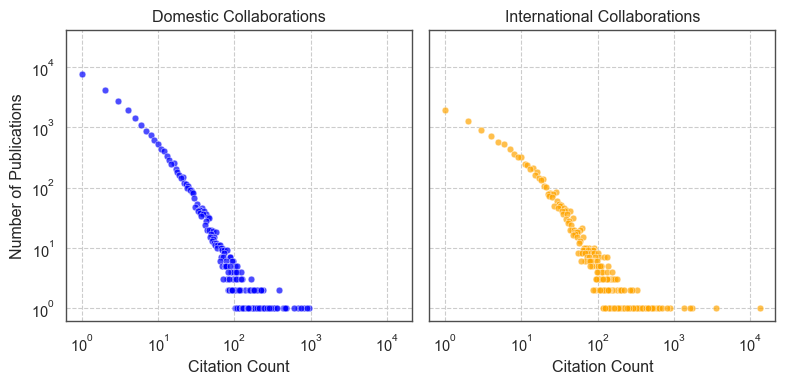

In [4]:
plot_citation_distribution(br_publications_df)
plt.show()

In [5]:
subfield_collabs_df = pd.read_csv("../../data/processed/7_publications_collab_types.csv")

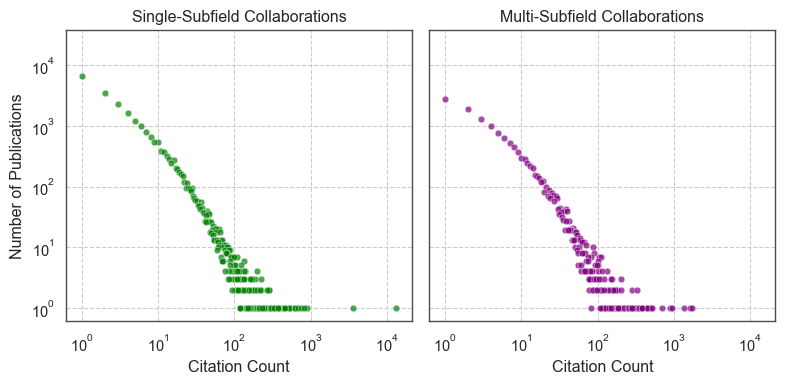

In [6]:
plot_subfield_collaboration(subfield_collabs_df)
plt.show()